**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from xgboost import XGBClassifier

from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import warnings

**EDA**

In [ ]:
df = pd.read_csv('data/raw.csv')

In [214]:
df.head()

,text,label
0,"resume: Skilled in julia, ruby, keras, Data An...",1
1,"resume: Expert in scala, Cloud Architect, BEng...",0
2,"resume: Expert in api, snowflake, agile method...",1
3,"resume: Skilled in power bi, redis, mysql, ker...",0
4,"resume: Experienced in docker, business intell...",1


In [215]:
df.shape

(3000, 2)

In [216]:
df['label'].value_counts()

label
1    1500
0    1500
Name: count, dtype: int64

We are going to implement two approaches to this problem. The goal is to predict hire/reject.
1. Since the data is in text form our first approach will be based around NLP preprocessing followed by vectorization. The backbone of this approach will be
a preprocessing function.
2. The second approach will be based around creating a parsing function that extracts relevant information from the resume data and engineer 
features to find signals that correspond to hire/reject.

**Preprocessing & Parsing functions**

In [217]:
# Word lemmatizer
lemmatizer=WordNetLemmatizer()

In [218]:
# Preprocessing function for text data
def preprocess(text):
    # 1. Define stopwords
    stop_words=stopwords.words('english')

    # 2. Tokenize text
    tokens=nltk.word_tokenize(text.lower())

    # 3. Apply lemmatizer, remove punctuation and remove stopwords from text
    return " ".join([
        lemmatizer.lemmatize(w) for w in tokens if w.isalnum() and w not in stop_words 
    ])

In [219]:
# Parsing function to obtain tabular data
def parse_row(text):
    # 1. Split resume and job
    resume_part, job_part = text.split("[sep] job:")
    resume_part = resume_part.replace("resume:", "").strip()
    job_part = job_part.strip()

    # 2. Job role + description + required experience
    job_role, job_desc = job_part.split(":", 1)
    job_role = job_role.strip()

    ignore_phrases = ["with focus", "for", "in a", "requires", "experience"]

    job_skills = [
        x.strip().lower()
        for x in job_desc.split(",")
        if not any(p in x.lower() for p in ignore_phrases)
    ]

    # Extract job experience
    job_experience = None
    for x in job_skills:
        if "year" in x or "senior" in x:
            num = ''.join(filter(str.isdigit, x))
            if num:
                job_experience = int(num)
            elif "senior" in x:
                job_experience = 7

    # 3. Resume parsing
    tokens = [x.strip() for x in resume_part.split(",")]

    resume_skills = []
    education = None
    experience = None

    edu_keywords = [
        "bs", "ms", "phd", "mba", "beng", "meng",
        "diploma", "ba", "doctor", "certificate"
    ]

    bad_edu_patterns = [
        "deployed", "collaborated", "built", "developed",
        "led", "optimized", "for global", "enterprise",
        "clients", "developer"
    ]

    noise_prefixes = [
        "experienced in", "expert in", "versed in",
        "contributed to", "accomplished in",
        "proficient in", "specialized in", "trained in", "skilled in"
    ]

    for t in tokens:
        t_lower = t.lower()

        # Education
        if any(x in t_lower for x in edu_keywords) and not any(b in t_lower for b in bad_edu_patterns):
            education = t.replace(" in ", " ")

        # Experience
        elif "year" in t_lower or "senior" in t_lower:
            num = ''.join(filter(str.isdigit, t_lower))
            if num:
                experience = int(num)
            elif "senior" in t_lower:
                experience = 7

        # Skills
        else:
            for p in noise_prefixes:
                t_lower = t_lower.replace(p, "").strip()

            resume_skills.append(t_lower)

    # 4. Final cleanup (remove experience from resume & job as they have seperate features now)
    job_skills = [x for x in job_skills if "year" not in x and "senior" not in x]
    resume_skills = [x for x in resume_skills if "year" not in x and "senior" not in x]

    # 5. Output
    return {
        "resume_text": resume_part,
        "resume_skills": resume_skills,
        "education": education,
        "experience (years)": experience,
        "job_role": job_role,
        "job_skills": job_skills,
        "job_experience (years)": job_experience
    }

In [220]:
df_text =  df.copy()
df_tabular = df.copy()

In [221]:
df_text['text'] = df_text['text'].apply(preprocess)

In [222]:
df_tabular = df_tabular['text'].apply(parse_row).apply(pd.Series)
df_tabular = pd.concat([df_tabular.drop(columns = 'resume_text'), df['label']], axis=1)

In [223]:
df_text.head()

,text,label
0,resume skilled julia ruby kera data analyst b ...,1
1,resume expert scala cloud architect beng compu...,0
2,resume expert api snowflake agile methodology ...,1
3,resume skilled power bi redis mysql kera types...,0
4,resume experienced docker business intelligenc...,1


In [224]:
df_tabular.head()

,resume_skills,education,experience (years),job_role,job_skills,job_experience (years),label
0,"[julia, ruby, keras, data analyst, data-driven...",BS Engineering,1,Software Engineer,[julia],1,1
1,"[scala, cloud architect, designed applications...",BEng Computer Science,7,Data Analyst,"[pandas, mongodb, plotly, snowflake, kotlin, gcp]",2,0
2,"[api, snowflake, agile methodologies, matplotl...",BA Engineering,5,Cloud Architect,[api],3,1
3,"[power bi, redis, mysql, keras, typescript, cl...",MEng Statistics,4,Data Scientist,"[aws, postgresql, pytorch]",1,0
4,"[docker, business intelligence, scikit learn, ...",MEng Statistics,4,DevOps Engineer,"[scikit learn, spark, business intelligence, d...",1,1


The text data will be fed to the models through the TF-IDF vectorizer and the tabular data will be fed through the
Multilabel Binarizer which will be stacked with additional features.

**Model evaluation prerequisites**

In [276]:
# Vectorizer for text-based approach
vec = TfidfVectorizer()

# Binarizer for tabular data approach
mlb = MultiLabelBinarizer()

In [226]:
# Models
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb = XGBClassifier()
sv = SVC()

In [227]:
# Hyperparamters for each model
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

sv_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

In [291]:
# Evaluation function with hyperparameter tuning for each model
def evaluate(model, param_dist, x_train, y_train):
    search = RandomizedSearchCV(
        model,
        param_distributions = param_dist,
        n_iter = 20,
        cv = 5,
        scoring = "accuracy",
        n_jobs = -1,
        random_state = 42
    )
    
    # Fit search
    search.fit(x_train, y_train)
    print(f"{model.__class__.__name__}:", search.best_params_)
    
    return search.best_estimator_

In [ ]:
# Function to compute model accuracy to select the best models
def model_accuracy(y_pred, y_test, model_name):
    print(f"{model_name}: {np.round(accuracy_score(y_test, y_pred), 4)}")

In [ ]:
# Metric plotting function
def plot_metrics(y_pred, y_test, model_name):
    cr = classification_report(y_test, y_pred)
    print(f"Classification Report for {model_name}:\n{cr}")

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Hire", "Hire"],
        yticklabels=["Not Hire", "Hire"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

**Text-based approach**

In [229]:
x_0 = df_text['text']
y_0 = df_text['label']

In [230]:
x_train_0, x_test_0, y_train_0, y_test_0 = train_test_split(
    x_0, y_0, test_size = 0.2, random_state = 42
)

In [231]:
x_train_0 = vec.fit_transform(x_train_0)
x_test_0 = vec.transform(x_test_0)

In [ ]:
warnings.filterwarnings("ignore")

In [246]:
# Hyperparameter tuning using RandomizedSearchCV 
print("--- Best Parameters for each model (Text-based approach) ---")
lr_txt = evaluate(lr, lr_params, x_train_0, y_train_0)
dt_txt = evaluate(dt, dt_params, x_train_0, y_train_0)
rf_txt = evaluate(rf, rf_params, x_train_0, y_train_0, y_test_0)
xgb_txt = evaluate(xgb, xgb_params, x_train_0, y_train_0)
sv_txt = evaluate(sv, sv_params, x_train_0, y_train_0)

--- Final models with hyperparameter tuning (Text-based approach) ---
LogisticRegression Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 100}
DecisionTreeClassifier Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
RandomForestClassifier Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
XGBClassifier Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
SVC Best Params: {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}


In [ ]:
# Predictions on text models
y_pred_lr_txt = lr_txt.predict(x_test_0)
y_pred_dt_txt = dt_txt.predict(x_test_0)
y_pred_rf_txt = rf_txt.predict(x_test_0)
y_pred_sv_txt = sv_txt.predict(x_test_0)
y_pred_xgb_txt = xgb_txt.predict(x_test_0)

In [ ]:
# Pick best models based on accuracy
print("--- Accuracy Scores (Text-based approach) ---")
model_accuracy(y_pred_lr_txt, "Logistic Regression")
model_accuracy(y_pred_dt_txt, "Decision Tree")
model_accuracy(y_pred_rf_txt, "Random Forest")
model_accuracy(y_pred_xgb_txt, "XGBoost")
model_accuracy(y_pred_sv_txt, "SVM")

--- Accuracy Scores (Text-based approach) ---
Logistic Regression: 0.9117
Decision Tree: 0.825
Random Forest: 0.8683
XGBoost: 0.9283
SVM: 0.9183


The best performance for the vectorized text-based approach was on XGBoost, SVM & Logistic Regression.

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       308
           1       0.88      0.98      0.93       292

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600



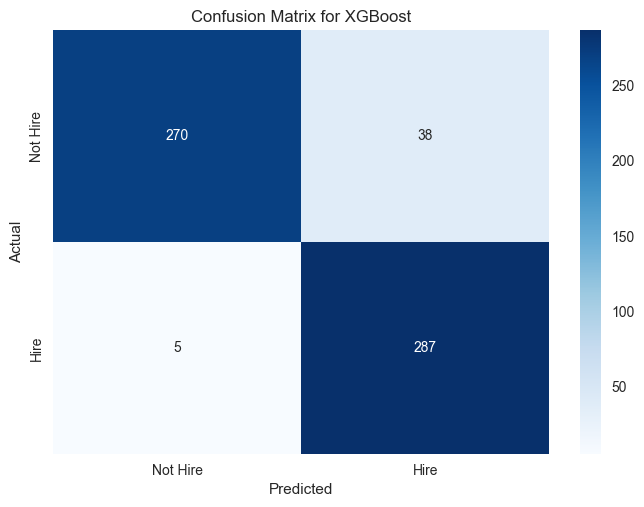

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.96      0.87      0.92       308
           1       0.88      0.97      0.92       292

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600



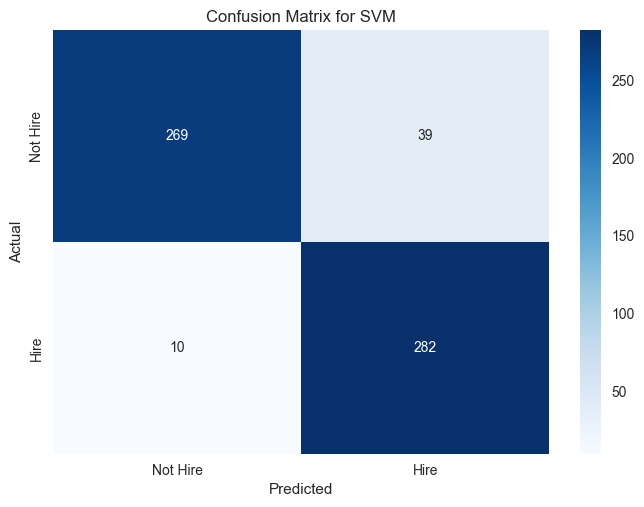

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       308
           1       0.87      0.97      0.91       292

    accuracy                           0.91       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.91      0.91       600



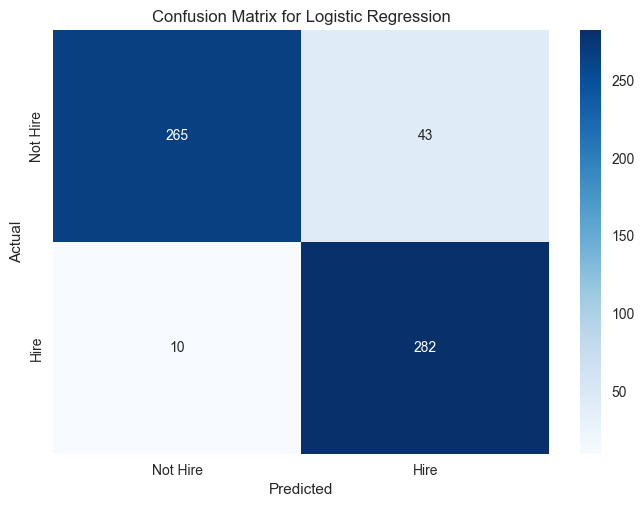

In [ ]:
# Plot metrics for best models
plot_metrics(y_pred_xgb_txt, y_test_0, "XGBoost")
plot_metrics(y_pred_sv_txt, y_test_0, "SVM")
plot_metrics(y_pred_lr_txt, y_test_0, "Logistic Regression")

**Tabular data approach**

In [275]:
df_tabular.head()

,resume_skills,education,experience (years),job_role,job_skills,job_experience (years),label
0,"[julia, ruby, keras, data analyst, data-driven...",BS Engineering,1,Software Engineer,[julia],1,1
1,"[scala, cloud architect, designed applications...",BEng Computer Science,7,Data Analyst,"[pandas, mongodb, plotly, snowflake, kotlin, gcp]",2,0
2,"[api, snowflake, agile methodologies, matplotl...",BA Engineering,5,Cloud Architect,[api],3,1
3,"[power bi, redis, mysql, keras, typescript, cl...",MEng Statistics,4,Data Scientist,"[aws, postgresql, pytorch]",1,0
4,"[docker, business intelligence, scikit learn, ...",MEng Statistics,4,DevOps Engineer,"[scikit learn, spark, business intelligence, d...",1,1


In [279]:
x_1 = df_tabular.drop(columns = 'label')
y_1 = df_tabular['label']

In [280]:
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(
    x_1, y_1, test_size = 0.2, random_state = 42
)

In [282]:
mlb_resume = MultiLabelBinarizer()
mlb_job = MultiLabelBinarizer()

In [288]:
# Apply binarizer on resume and job columns (as they contain lists)
resume_encoded_train = csr_matrix(mlb_resume.fit_transform(x_train_1['resume_skills']))
resume_encoded_test = csr_matrix(mlb_resume.transform(x_test_1['resume_skills']))

job_encoded_train = csr_matrix(mlb_job.fit_transform(x_train_1['job_skills']))
job_encoded_test = csr_matrix(mlb_job.transform(x_test_1['job_skills']))

# Numeric columns stay as is
resume_exp_train = csr_matrix((x_train_1['experience (years)'].values.reshape(-1, 1)))
resume_exp_test = csr_matrix(x_test_1['experience (years)'].values.reshape(-1, 1))

job_exp_train = csr_matrix(x_train_1['job_experience (years)'].values.reshape(-1, 1))
job_exp_test = csr_matrix(x_test_1['job_experience (years)'].values.reshape(-1, 1))

In [289]:
# Stack the columns into a matrix
x_train_1 = hstack([
    resume_encoded_train,
    job_encoded_train,
    resume_exp_train,
    job_exp_train
])

x_test_1 = hstack([
    resume_encoded_test,
    job_encoded_test,
    resume_exp_test,
    job_exp_test
])

In [297]:
# Hyperparameter tuning using RandomizedSearchCV 
print("--- Best Parameters for each model (Text-based approach) ---")
lr_tab = evaluate(lr, lr_params, x_train_1, y_train_1)
dt_tab = evaluate(dt, dt_params, x_train_1, y_train_1)
rf_tab = evaluate(rf, rf_params, x_train_1, y_train_1)
xgb_tab = evaluate(xgb, xgb_params, x_train_1, y_train_1)
sv_tab = evaluate(sv, sv_params, x_train_1, y_train_1)

--- Best Parameters for each model (Text-based approach) ---
LogisticRegression: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
DecisionTreeClassifier: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
RandomForestClassifier: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
XGBClassifier: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
SVC: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10}


In [ ]:
# Predictions on tabular models
y_pred_lr_tab = lr_tab.predict(x_test_1)
y_pred_dt_tab = dt_tab.predict(x_test_1)
y_pred_rf_tab = rf_tab.predict(x_test_1)
y_pred_sv_tab = sv_tab.predict(x_test_1)
y_pred_xgb_tab = xgb_tab.predict(x_test_1)

In [300]:
# Pick best models based on accuracy
print("--- Accuracy Scores (Tabular data approach) ---")
model_accuracy(y_pred_lr_tab, y_test_1, "Logistic Regression")
model_accuracy(y_pred_dt_tab, y_test_1, "Decision Tree")
model_accuracy(y_pred_rf_tab, y_test_1, "Random Forest")
model_accuracy(y_pred_xgb_tab, y_test_1, "XGBoost")
model_accuracy(y_pred_sv_tab, y_test_1, "SVM")

--- Accuracy Scores (Text-based approach) ---
Logistic Regression: 0.8883
Decision Tree: 0.8967
Random Forest: 0.9083
XGBoost: 0.9567
SVM: 0.8867


Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       308
           1       0.92      1.00      0.96       292

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



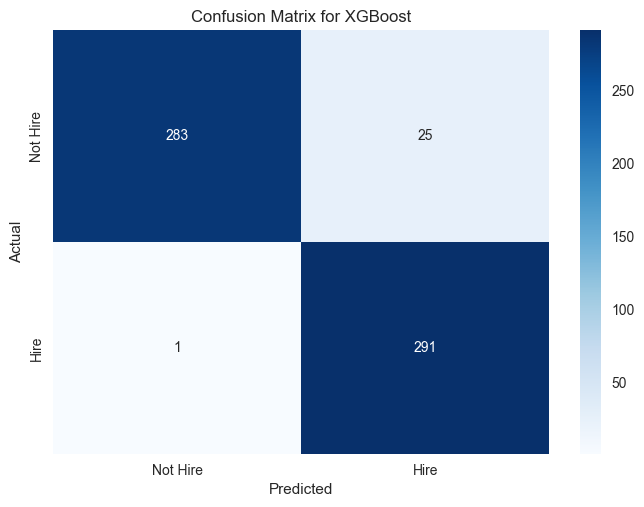

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       308
           1       0.84      1.00      0.91       292

    accuracy                           0.91       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.91      0.91       600



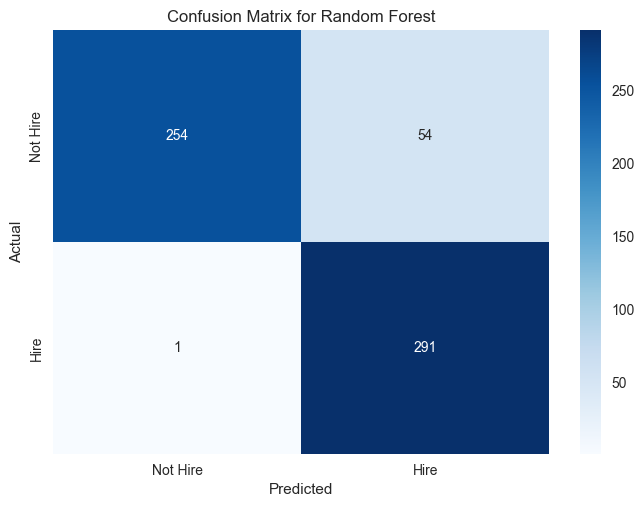

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89       308
           1       0.84      0.97      0.90       292

    accuracy                           0.90       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.91      0.90      0.90       600



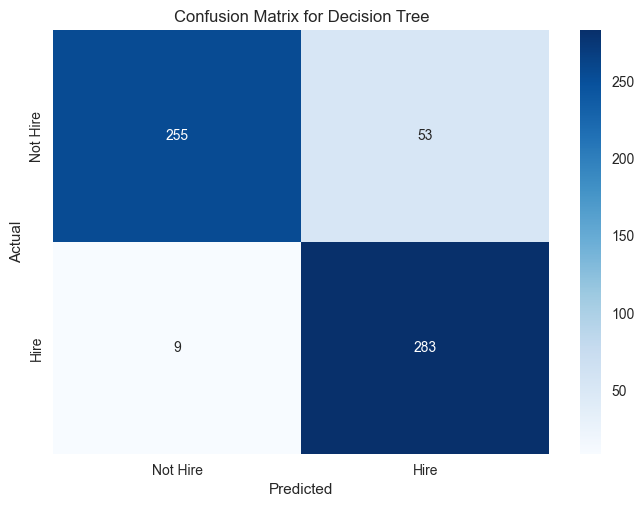

In [301]:
# Plot metrics for best models
plot_metrics(y_pred_xgb_tab, y_test_0, "XGBoost")
plot_metrics(y_pred_rf_tab, y_test_0, "Random Forest")
plot_metrics(y_pred_dt_tab, y_test_0, "Decision Tree")

While XGBoost is performing very well here the other models are fairly similar in performance to the text based approach. In the current approach we derived meaningful features from the text data but fed them to the model all at once. The model can't distinguish between resume and job inputs. We have to help the model see a relationship between a candidate's resume and job requirements.

A great way to capture hire/reject could be a feature which simply calculates what percentage of the required job skills a candidate possesses. Additionally we can calculate the gap in a candidate's experience vs the required job experience.

In [302]:
def skill_match_score(resume_skills, job_skills):
    resume_set = set(resume_skills)
    job_set = set(job_skills)
    
    if len(job_set) == 0:
        return 0.0
    
    intersection = resume_set & job_set
    score = len(intersection) / len(job_set)
    
    return score

In [ ]:
df_tabular['match_score'] = df_tabular.apply(lambda row: skill_match_score(row['resume_skills'], row['job_skills']), axis=1)

In [305]:
def experience_gap(resume_exp, job_exp):
    return resume_exp-job_exp

In [306]:
df_tabular['experience_gap'] = df_tabular.apply(lambda row: experience_gap(row['experience (years)'], row['job_experience (years)']), axis=1)

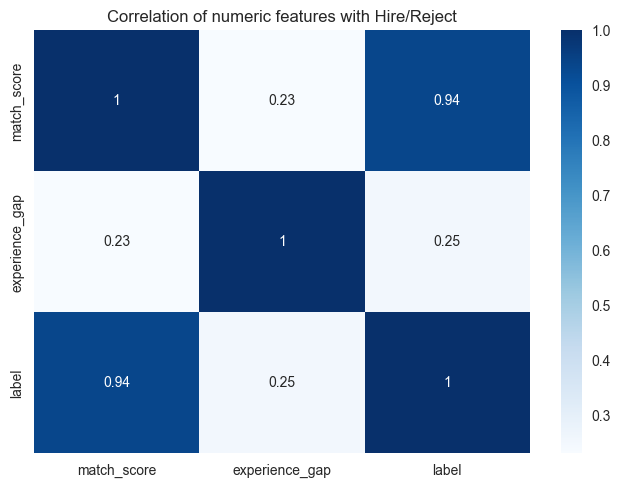

In [315]:
df_num = df_tabular[['match_score', 'experience_gap', 'label']]
corr = df_num.corr()
sns.heatmap(corr, annot=True, cmap = 'Blues')
plt.title("Correlation of numeric features with Hire/Reject")
plt.show()

As we can see match_score is a very strong indicator of job hire and experience_gap also gives a strong signal, although not as much. We will retrain our model with these new features.

In [317]:
x_1 = df_tabular.drop(columns = 'label')
y_1 = df_tabular['label']

In [320]:
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(
    x_1, y_1, test_size = 0.2, random_state = 42
)

In [323]:
match_score_train = csr_matrix((x_train_1['match_score'].values.reshape(-1, 1)))
match_score_test = csr_matrix(x_test_1['match_score'].values.reshape(-1, 1))

exp_gap_train = csr_matrix(x_train_1['experience_gap'].values.reshape(-1, 1))
exp_gap_test = csr_matrix(x_test_1['experience_gap'].values.reshape(-1, 1))

In [324]:
x_train_1 = hstack([
    resume_encoded_train,
    match_score_train,
    exp_gap_train
])

x_test_1 = hstack([
    resume_encoded_test,
    match_score_test,
    exp_gap_test
])

In [325]:
# Hyperparameter tuning using RandomizedSearchCV 
print("--- Best Parameters for each model (Text-based approach) ---")
lr_tab = evaluate(lr, lr_params, x_train_1, y_train_1)
dt_tab = evaluate(dt, dt_params, x_train_1, y_train_1)
rf_tab = evaluate(rf, rf_params, x_train_1, y_train_1)
xgb_tab = evaluate(xgb, xgb_params, x_train_1, y_train_1)
sv_tab = evaluate(sv, sv_params, x_train_1, y_train_1)

--- Best Parameters for each model (Text-based approach) ---
LogisticRegression: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
DecisionTreeClassifier: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}
RandomForestClassifier: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
XGBClassifier: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
SVC: {'kernel': 'rbf', 'gamma': 0.001, 'C': 10}


In [326]:
# Predictions on tabular models
y_pred_lr_tab = lr_tab.predict(x_test_1)
y_pred_dt_tab = dt_tab.predict(x_test_1)
y_pred_rf_tab = rf_tab.predict(x_test_1)
y_pred_sv_tab = sv_tab.predict(x_test_1)
y_pred_xgb_tab = xgb_tab.predict(x_test_1)

In [327]:
# Pick best models based on accuracy
print("--- Accuracy Scores (Tabular data approach) ---")
model_accuracy(y_pred_lr_tab, y_test_1, "Logistic Regression")
model_accuracy(y_pred_dt_tab, y_test_1, "Decision Tree")
model_accuracy(y_pred_rf_tab, y_test_1, "Random Forest")
model_accuracy(y_pred_xgb_tab, y_test_1, "XGBoost")
model_accuracy(y_pred_sv_tab, y_test_1, "SVM")

--- Accuracy Scores (Tabular data approach) ---
Logistic Regression: 0.9817
Decision Tree: 0.9833
Random Forest: 0.985
XGBoost: 0.9767
SVM: 0.9833


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       308
           1       0.99      0.98      0.98       292

    accuracy                           0.98       600
   macro avg       0.99      0.98      0.98       600
weighted avg       0.99      0.98      0.98       600



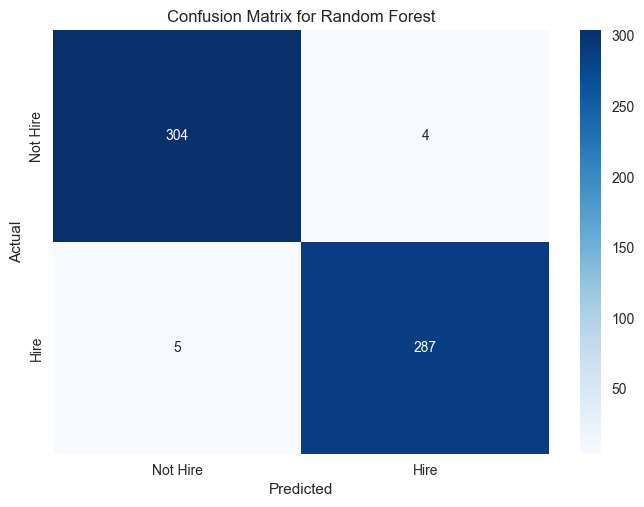

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       308
           1       0.98      0.98      0.98       292

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



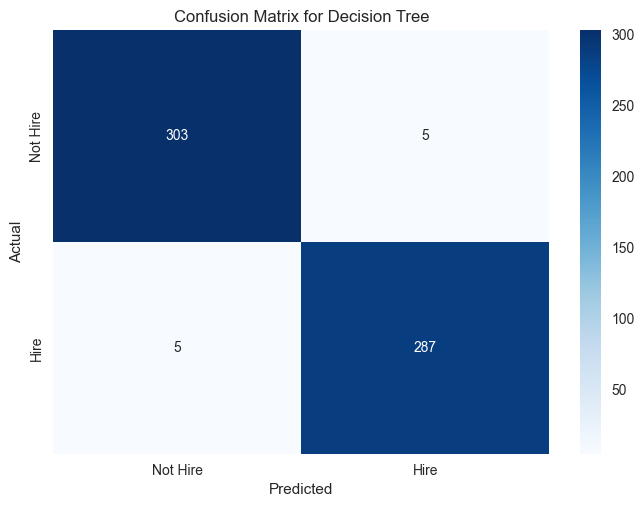

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       308
           1       0.98      0.99      0.98       292

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



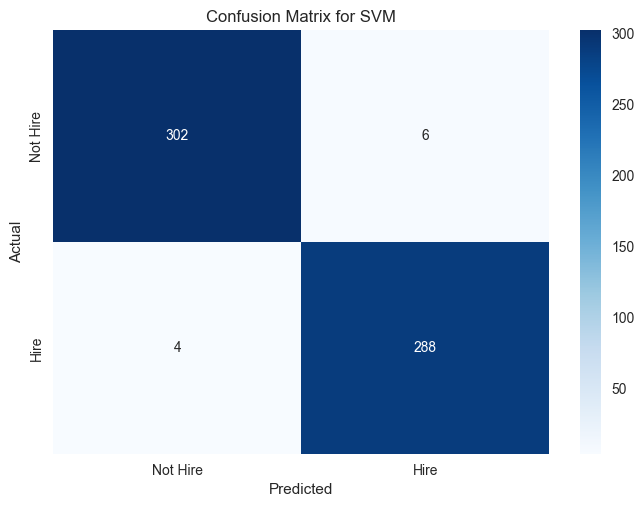

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       308
           1       0.98      0.99      0.98       292

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



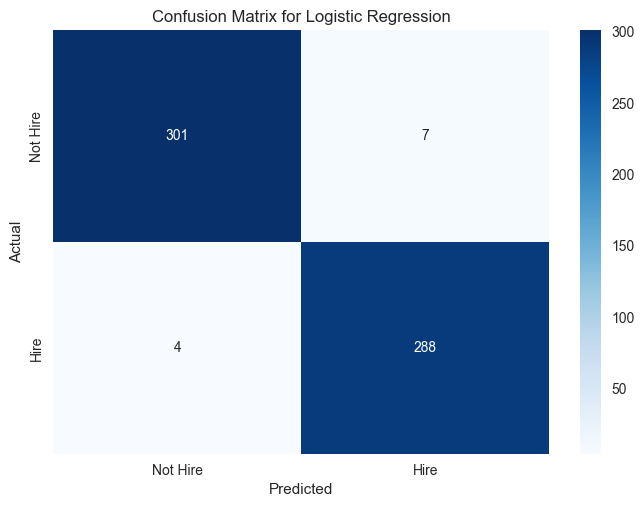

In [328]:
# Plot metrics for best models
plot_metrics(y_pred_rf_tab, y_test_0, "Random Forest")
plot_metrics(y_pred_dt_tab, y_test_0, "Decision Tree")
plot_metrics(y_pred_sv_tab, y_test_0, "SVM")
plot_metrics(y_pred_lr_tab, y_test_0, "Logistic Regression")

As we can see adding the match_score feature helped the models see a very clear pattern between candidate resumes and job requirements. Almost all models are performing with an accuracy score of ~0.98 with very few mistakes!

In [ ]:
LogisticRegression.predict_proba(x_test_1[0])